# **Comfort algorithms**
Comofort can be measure in many ways

#**1.Temperature**

It can be simply the indoor temprature ($T_i$), or the operative temperature ($T_{op}$). While it gives some reference to the building occupant comfort it does not cover it completely.

-------------------------------------------------

Rough approx. of $T_{op}$ and its relation to $PMV$:
🔹 4. Typical ranges / interpretations
Operative Temp (°C)	Typical PMV (for sedentary, 0.1 m/s, 1.2 met, 0.5 clo)	Thermal sensation

20 °C	≈ -1.0	Slightly cool

22 °C	≈ -0.3	Neutral/slightly cool

24 °C	≈ +0.2	Neutral/slightly warm

26 °C	≈ +0.7	Slightly warm

28 °C	≈ +1.2	Warm

So PMV ≈ 0 corresponds roughly to
$T_op$≈22-24°C

≈22-24°C for typical office conditions

----------------------------------------------------

Ref:

https://en.wikipedia.org/wiki/Operative_temperature

https://www.simscale.com/docs/simwiki/cfd-computational-fluid-dynamics/mean-radiant-temperature-operative-temperature-cfd/

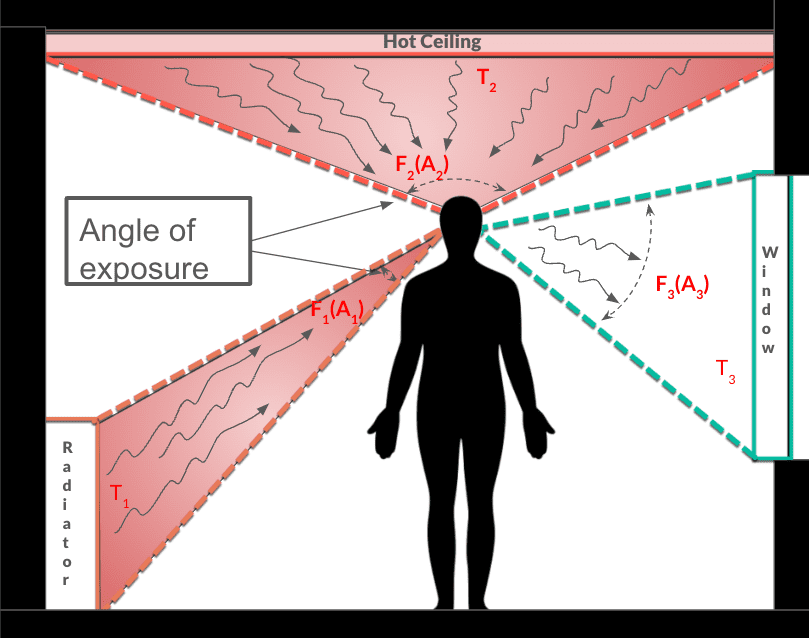

# **2. PMV and PPD**

Predicted Mean Vote (PMV) and Predicted Percentage Dissatisfied (PPD) are indices represeting the occupants satisfaction and dissatisfaction. PMV is an index between -3 to +3 which shows the thermal comofrt as described in fig. 01


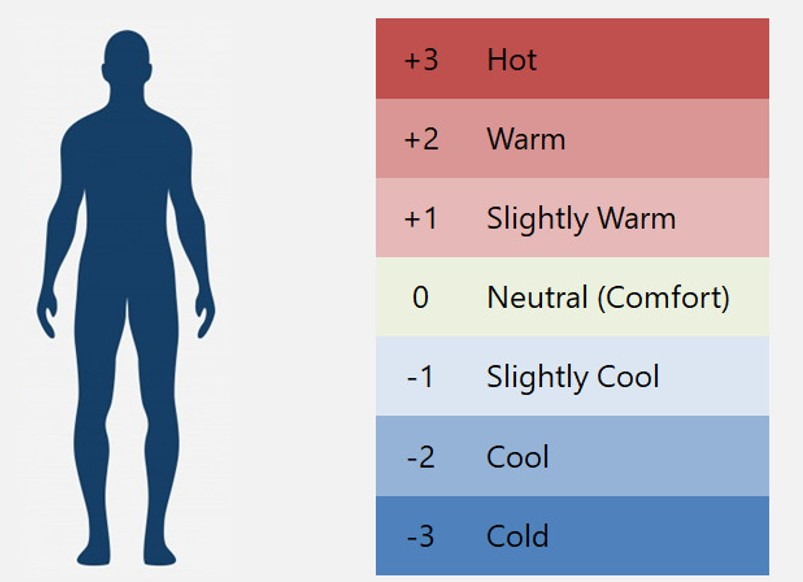
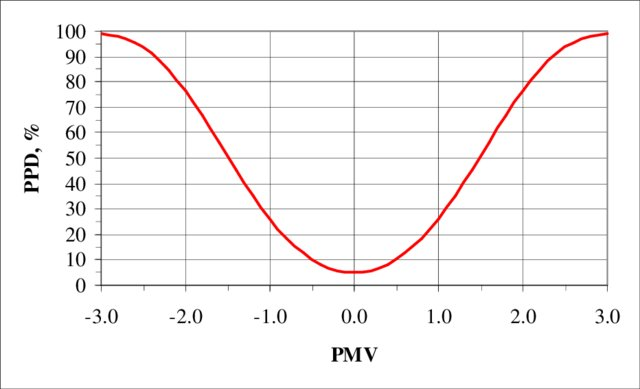
Fig.01: the scale and relation of PMV and PPD (which is statistically calculated based on PMV)

PPD is a statistical index predicting the number of dissatisfied occupants



The PMV index is based on ISO 7730. It calculates the PMV and PPD comfort indices of the building. It is based on the assumption that:


Assumptions: RH = 50% (or measured), v = 0.1 m/s, M = 1.2 met, I_cl = 0.5 clo.

T_a: indoor air temperature (can be calulated by an RC model)

T_mrt: is the mean radiant temperature can be set as the internal wall temperature ($T_m$) in the 3 state (e.g. 3R3C or 5R3C) state-space model.

RH: This is the problem still ???? Right now we can approximate it to 40–60% RH — use 50% as a neutral default. If you expect winter heating (dry), use 30–40%, if humid climates/AC use 50–60%. (acc. to GPT)

met: approximately 1.2 met,

Clo: approximated as 0.5

Ref:

https://en.wikipedia.org/wiki/Thermal_comfort#PMV/PPD_method

https://www.iso.org/standard/85803.html

METHOD 01

In [ ]:
#Method #1 (calcuation based on ISO standard)
import math

def _sat_vapor_pressure_pa(T_C):
    """Saturation vapor pressure in Pa"""
    return 610.78 * math.exp((17.27 * T_C) / (T_C + 237.3))

def pmv_ppd(T_a, T_mrt, RH, v, met, clo):
    """
    PMV/PPD calculation based on ISO 7730 standard (no nonstandard energy balance terms)
    """
    M = met * 58.15  # metabolic rate [W/m2]
    W = 0.0  # external work [W/m2]
    I_cl = clo * 0.155  # clothing insulation [m2K/W]
    f_cl = 1.05 + 0.1 * clo if I_cl > 0 else 1.0
    pa = RH / 100.0 * _sat_vapor_pressure_pa(T_a)  # water vapor partial pressure [Pa]

    # Initial guess for clothing surface temp
    t_cl = T_a + (35.5 - T_a) / (3.5 * I_cl + 0.1)  # better initial guess

    # Iterate to solve for t_cl
    for _ in range(150):
        t_cl_old = t_cl
        t_cl_K = t_cl + 273.15
        t_a_K = T_a + 273.15
        t_r_K = T_mrt + 273.15

        h_r = 4.0 * 0.95 * 5.67e-8 * ((t_cl_K + t_r_K) / 2.0) ** 3  # radiative
        h_c = max(12.1 * math.sqrt(v), 2.38 * abs(t_cl - T_a) ** 0.25)  # convective
        h_t = h_r + h_c

        t_cl = (35.7 - 0.028 * M + I_cl * f_cl * h_t * T_a) / (1 + I_cl * f_cl * h_t)

        if abs(t_cl - t_cl_old) < 0.01:
            break

    # Heat losses
    #H_r = h_r * f_cl * (t_cl - T_mrt)
    H_r = 0.95 * 5.67e-8 * f_cl * ((t_cl_K ** 4) - (t_r_K ** 4))
    H_c = h_c * f_cl * (t_cl - T_a)
    E_res = 0.0173 * M * (5.867 - pa / 1000.0)
    C_res = 0.0014 * M * (34.0 - T_a)

    # PMV formula
    PMV = (0.303 * math.exp(-0.036 * M) + 0.028) * (
        (M - W) - H_r - H_c - E_res - C_res
    )

    # PPD formula
    PPD = 100.0 - 95.0 * math.exp(-0.03353 * PMV ** 4.0 - 0.2179 * PMV ** 2.0)
    print(f"Ta={T_a}, t_cl={t_cl:.2f}, H_c={H_c:.2f}, H_r={H_r:.2f}, PMV={PMV:.2f}")
    return PMV, PPD

In [ ]:
#SANITY CHECK: PMV ~ -0.26, PPD < 10%
pmv, ppd = pmv_ppd(
    T_a=22.0, T_mrt=22.0,
    RH=50, v=0.1,
    met=1.2, clo=1
)
print(f"PMV={pmv:.2f}, PPD={ppd:.1f}%")


In [ ]:
for Ta in range(20, 27):
    pmv, ppd = pmv_ppd(Ta, T_mrt=Ta, RH=50, v=0.1, met=1.2, clo=0.5)
    print(f"Ta={Ta}°C → PMV={pmv:.2f}, PPD={ppd:.1f}%")

Method #2 (Existing library)

In [ ]:
#This method is nonlinear which makes it hard to use in RC dynamic calculation of the building
pip install pythermalcomfort

In [ ]:
from pythermalcomfort.models import pmv_ppd_iso
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
# Calculate PMV and PPD using ISO 7730 standard
result = pmv_ppd_iso(
    tdb=21,  # Dry Bulb Temperature in °C
    tr=20,  # Mean Radiant Temperature in °C
    vr=0.1,  # Relative air speed in m/s
    rh=50,  # Relative Humidity in %
    met=1.2,  # Metabolic rate in met
    clo=1,  # Clothing insulation in clo
    model="7730-2005"  # Year of the ISO standard
)
print(f"PMV: {result.pmv}, PPD: {result.ppd}")

#pmv_ppd_iso(tdb=22, tr=22, vr=0.1, rh=50, met=1.2, clo=1, model="7730-2005")